# Fruit Object Detection

![](http://)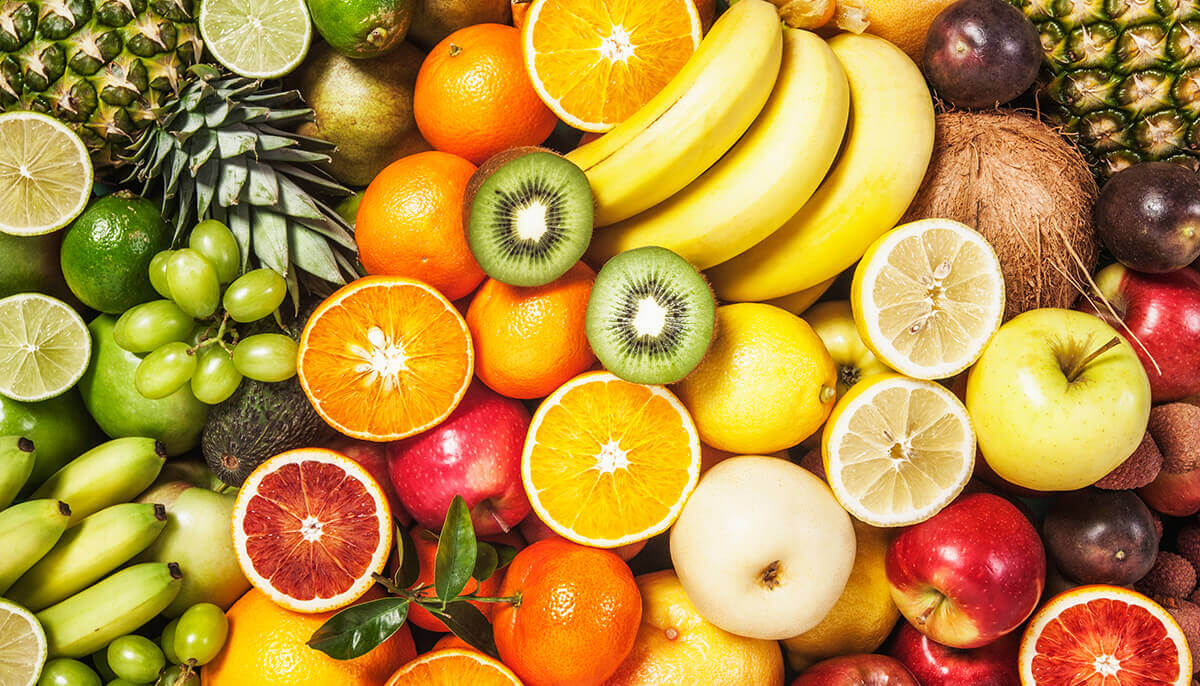

In [1]:
from IPython import display
display.clear_output()

!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 5.8 MB/s eta 0:00:00a 0:00:01


In [2]:
#import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import glob
import torch.nn as nn
import torch
from torchvision import transforms, datasets
from PIL import Image, ImageDraw, ImageFont
from torch.utils.data import Dataset, DataLoader
from ultralytics import YOLO
from IPython import display
import random

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
#activate gpu
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

# Prepare datasets

In [4]:
#dirs
data = '../input/fruit-detection/Fruits-detection' 

traindir    = os.path.join(data, 'train/images')
trainlabels = os.path.join(data,'train/labels') 

valdir    = os.path.join(data,'valid/images') 
vallabels = os.path.join(data,'valid/labels' )

In [5]:
def files(images, labels):
    image_files = glob.glob(os.path.join(images, '*.jpg'))
    labels_files = glob.glob(os.path.join(labels, '*.txt'))
    
    return image_files, labels_files

In [6]:
#files
train_image_files, train_labels_files = files(traindir, trainlabels)
val_image_files, val_labels_files = files(valdir, vallabels)

train_image_files.sort()
train_labels_files.sort()
val_image_files.sort()
val_labels_files.sort()

In [7]:
print(len(train_image_files), len(train_labels_files))

7108 7108


In [8]:
class dataset(Dataset):
    def __init__(self, image_paths, label_paths, transform=None, draw_box= False):
        self.image_paths = image_paths
        self.label_paths = label_paths
        self.transform = transform
        self.draw_box = draw_box
        
    def __getitem__(self, index):
        image_path = self.image_paths[index]
        label_path = self.label_paths[index]
        
        labels = []
        image = Image.open(image_path)
        image = image.resize((500, 500))
        draw = ImageDraw.Draw(image)

        classes = ['Apple', 'Banana', 'Grape', 'Orange', 'Pineapple', 'Watermelon'] 
        colors = ['yellow', 'red', 'pink', 'green', 'blue', 'orange']
        # Open the file and read its content
        with open(label_path, 'r') as file:
            lines = file.readlines()

        for line in lines:
            if line.strip():
                parts = line.strip().split()
                class_num = int(parts[0])
                x_center = float(parts[1])
                y_center = float(parts[2])
                width = float(parts[3])
                height = float(parts[4])

                x_min = int((x_center - width / 2) * 500)
                y_min = int((y_center - height / 2) * 500)
                x_max = int((x_center + width / 2) * 500)
                y_max = int((y_center + height / 2) * 500)

                labels.append((class_num, x_min, y_min, x_max, y_max))
                if self.draw_box == True:
                    draw.rectangle([x_min, y_min, x_max, y_max], outline= colors[class_num], width=10)
                    draw.text((x_min, y_min), f"{classes[class_num]}", fill= 'white')

        if self.transform:
            image = self.transform(image)

        return image, labels
            
    def __len__(self):
        return len(self.image_paths)
        

In [9]:
train_dataset = dataset(train_image_files, train_labels_files, None, True)
val_dataset = dataset(val_image_files, val_labels_files, None, False)

# Show some images with its labels and box

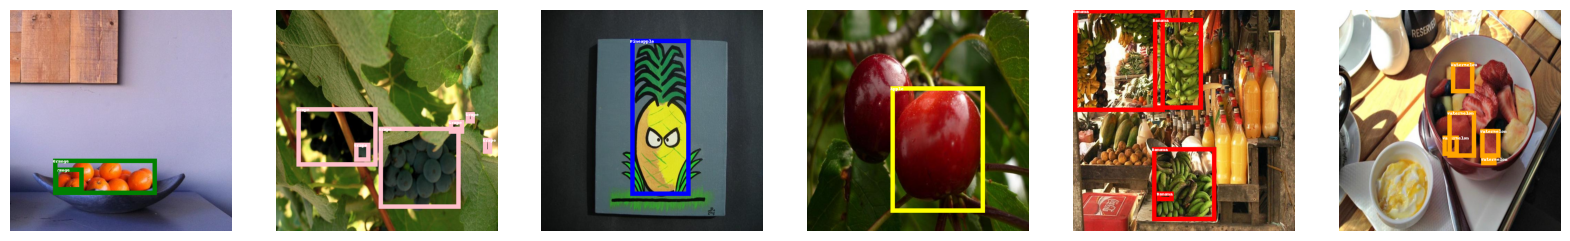

In [10]:
indxs = [603,160, 900, 20, 446, 80]
temp =0
fig, axes = plt.subplots(1, 6, figsize=(20, 10))
for i in indxs:
        image, labels = train_dataset[i]
        axes[temp].imshow(image)
        axes[temp].axis('off')
        temp = temp +1
        
plt.show()

# Training and validation

In [11]:
model = YOLO('yolov8n.pt')

In [12]:
import yaml
from pathlib import Path
import wandb
wandb.init(mode='disabled')


data = {
    'train': "/kaggle/input/fruit-detection/Fruits-detection/train",
    'val': "/kaggle/input/fruit-detection/Fruits-detection/valid",
    'nc': 6,  
    'names' : 
        ['Apple',
         'Banana',
         'Grape',
         'Orange',
         'Pineapple', 
         'Watermelon' ]
}

with open('data.yaml', 'w') as file:
    yaml.dump(data, file)

yaml_path = 'data.yaml'

#os.system('python train.py --img 500 --batch 16 --epochs 20 --data data.yaml --weights yolov8s.pt')
model.train(data=yaml_path, imgsz=500, batch=32, epochs=20)

Ultralytics 8.4.9 🚀 Python-3.10.13 torch-2.1.2 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=500, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0,

2026-02-01 15:55:14,645	INFO util.py:124 -- Outdated packages:
  ipywidgets==7.7.1 found, needs ipywidgets>=8
Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2026-02-01 15:55:15,282	INFO util.py:124 -- Outdated packages:
  ipywidgets==7.7.1 found, needs ipywidgets>=8
Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


Overriding model.yaml nc=80 with nc=6

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      7360  ultralytics.nn.modules.block.C2f             [32, 32, 1, True]             
  3                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  4                  -1  2     49664  ultralytics.nn.modules.block.C2f             [64, 64, 2, True]             
  5                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  6                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  7                  -1  1    295424  ultralytics

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7ea5ac3a8610>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
     

In [13]:
model.val(data=yaml_path)

Ultralytics 8.4.9 🚀 Python-3.10.13 torch-2.1.2 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,818 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 87.2±33.1 MB/s, size: 52.4 KB)
val: Scanning /kaggle/input/fruit-detection/Fruits-detection/valid/labels... 914 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 914/914 946.7it/s 1.0s0.0s
val: /kaggle/input/fruit-detection/Fruits-detection/valid/images/3d3ddc3054b32eb7_jpg.rf.03e7789aaf5212e2634b84ef502e0832.jpg: 1 duplicate labels removed
WARNING ⚠️ val: Cache directory /kaggle/input/fruit-detection/Fruits-detection/valid is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 58/58 6.3it/s 9.2s<0.1s
                   all        914       3227      0.634      0.447      0.485      0.329
                 Apple        188        557      0.663      0.479      0.516      0.352
                Banan

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7ea49c5590c0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
     

# save the model

In [15]:
model.save('/kaggle/working/best.pt')